In [1]:
import sys
import os
sys.path.insert(1, os.path.abspath('../../general_functions'))
sys.path.insert(0, os.path.abspath('./functions'))

import matplotlib.pyplot as plt
import numpy as np
from functions import *
import pandas as pd

from nb_toc import toc, back_to_toc, setup
setup()

toc([
    "Arcminutes and arcseconds",
    "Direct Imaging",
    "Angular separation and small-angle approximation",
    "The Rayleigh criterion",
    "Star-planet contrast",
    "Visualizing the direct imaging technique",
    "Astrometry"
    ])

<IPython.core.display.Javascript object>

## Arcminutes and arcseconds
This schematic showing how arminutes and arcseconds is provided for your reference with this notebook as it will come in handy when working through the direct-imaging method. These appear quite often in astronomy and planetary science and are worth working to commit to memory. 
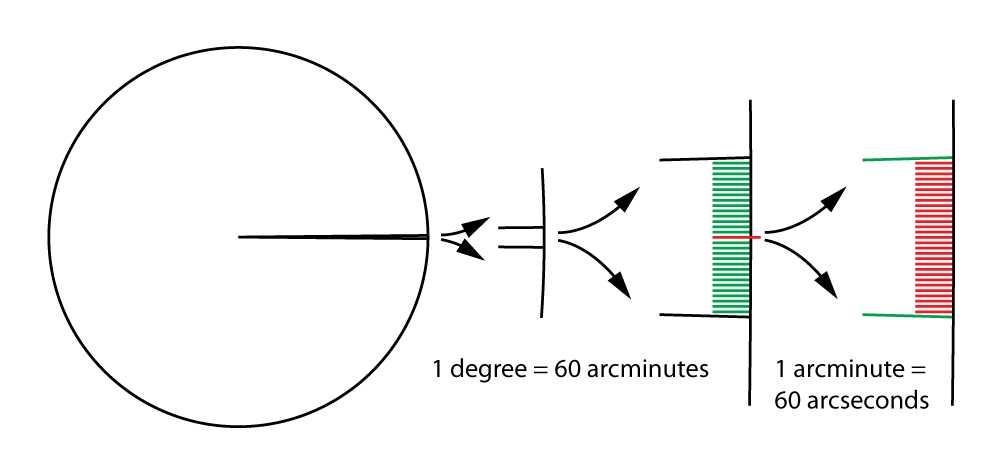

##### <span style="color:white">Direct Imaging</span>
### 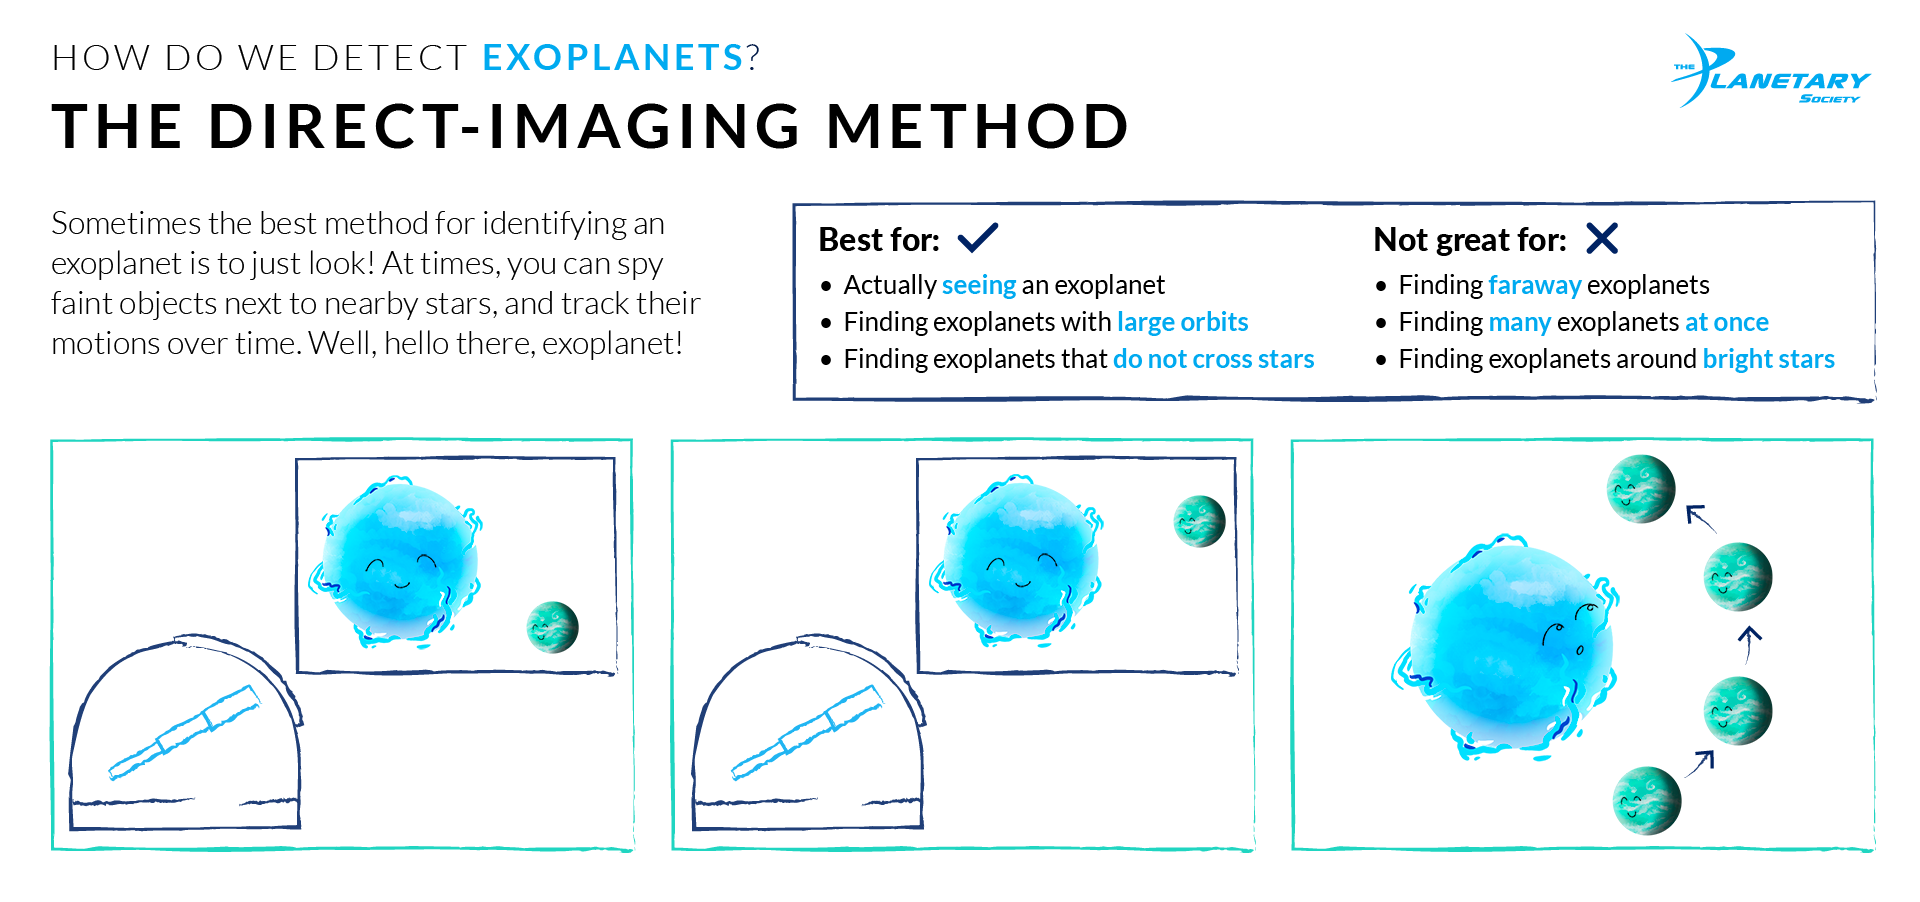

## Angular separation and small angle approximation
Consider the configuration below: a planet with a semi-major axis, a, that is a distance d away from us (the observer). 

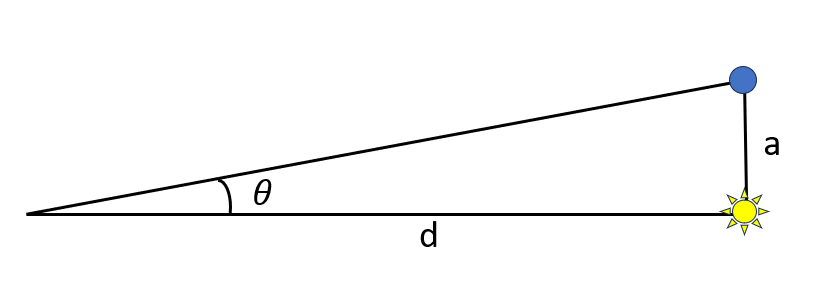

We will see an angular separation between the star and planet given by

$$\LARGE \theta \simeq \frac{a}{d}$$

Convince yourself that the small angle approximation is valid. Look at the NEA data for [Prox Cen b](https://exoplanetarchive.ipac.caltech.edu/overview/proxima%20centauri%20c), our nearest planetary neighbor. How much does the small angle approximation differ from the exact solution for this planet? How about a hypothetical planet around Prox Cen with an orbital distance equal to that of Neptune's (a $\simeq 30$ AU)? Twice that? At what approximate semi-major axis is the fractional difference between the approximation and exact solution $\sim 1\%$? How does this orbital distance compare with the orbits of things in are Solar Systems? In other words, if someone on Prox Cen b was observing the Solar System, where would the small angle approximation break down from the exact solution if they are trying to keep the error to < 1\%?

$\textbf{Note}$: make sure your units are consistent between a and d!!

## The Rayleigh criterion

For a telescope with diameter D observing at some wavelength $\lambda$, the minimum resolvable angular seperation is determined by the [Rayleigh criterion](http://hyperphysics.phy-astr.gsu.edu/hbase/phyopt/Raylei.html).

$$\LARGE \theta_{min} \simeq 1.22 \frac{\lambda}{D}$$

To resolve the planet from the star then the following must be satisfied:

$$\LARGE \frac{a}{d} \geq \theta_{min}$$

Just looking at the equation above, discuss with your classmates what semi-major axes and distances are favored by this technique.

## Star-planet contrast

Assuming the above is satisfied for whatever planet you are looking at, then whether or not you can actually image the planet depends on how much light it gives off and how much it constrasts the host star. The planet will both emit its own light (blackbody radiation) and reflect some fraction of the host star's light. The contrast between star and planet ($f$) is then the combination of the contrast between the thermal emission of star and planet ($f_\mathrm{thermal}$ and the fraction of star light that the planet reflects ($f_\mathrm{reflected}$), or

$$\LARGE f = f_\mathrm{reflected} + f_\mathrm{thermal}$$

The fraction of the star's light that is reflected by a planet is given via:

$$\LARGE f_\mathrm{reflected} = \frac{\pi R_p^2}{4\pi a^2}A$$

where $A$ is the planet's albedo, which is a measure of the fraction of $\textit{incoming}$ light that is reflected by the planet. A planet with a rocky surface will have a lower albedo than a planet with an icy surface. At this point in the course, you should have all the pieces you need to figure out how to derive the equation for $f_\mathrm{reflected}$. Talk through the derivation with your coursemates.

The star-planet contrast of thermal light is given via: 

$$\LARGE f_\mathrm{thermal} = \left(\frac{R_p}{R_\star}\right)^2 \frac{B_\lambda (T_p)}{B_\lambda (T_\star)} = \left(\frac{R_p}{R_\star}\right)^2 \frac{e^{hc/\lambda k T_\star} - 1}{e^hc/\lambda k T_p - 1}$$

where $T_p$ is the temperature of the planet, $T_\star$ is the temperature of the star, $h$ is Planck's constant, $c$ is the speed of light, $k$ is Boltzmann's constant, and $B_\lambda$ is the Planck function expressed in terms of wavelength. You will often see the Planck function expressed in terms of frequency ($\nu$), or $B_\nu$. 

Here, we will assume that $T_p$ is the equilibrium temperature of the planet, or 

$$\LARGE T_p \approx T_\star (1-A)^{1/4} sqrt{\frac{R_\star}{2a}}.$$

This approximation is often wrong by a good margin. For example, you can try calculating it for Venus and comparing with its actual temperature. But, unless we have more information to inform the $T_p$ of an exoplanet, this is usually the best we can do when modelling and trying to identify the best targets for direct imaging. Planet equilibrium temperatures will be discussed in more detail during the habitable zone module.

The trick with direct imaging is (1) determing whether the planet will be resolvable from its host with your telescope, and, if so, (2) trying to find the wavelength range where the star-planet contrast is maximized, and (3) whether you detect the maximum contrast with your detector, i.e., the contrast signal is significantly larger than the noise floor of the detector.

## Visualizing the direct imaging technique
The plot below contains for sub-panels takes the following input parameters:

- D = telescope diameter in meters.
- R_planet = radius of planet in Earth radii.
- A = planet's (bond) albedo. Cany be any number between [0 and 1).
- a = orbital semi-major axis of the planet in AU.
- dist_to_star = distance to the planet's host star in light-years.
- T_star = temperature of the planet's host star.
- R_star = radius of planet's host star in Solar radii.

The figure subplots show the following:
    
$\textbf{Top Left}$: the orbital semi-major axis of a planet vs the distance between the Earth and the star. The gray region corresponds to unresolvable angular seperations per the Rayleigh criterion, where the observational wavelength is calculated according to [Wein's Law](http://hyperphysics.phy-astr.gsu.edu/hbase/quantum/wien2.html). The input planet is shown as a red circle.

$\textbf{Top Right}$: cumulative histogram of all planet hosts within 100 lyr of our Solar System as a function of their distances. The input distance to the system is shown as a vertical red line. In other words, this subplot shows the number of systems where you would be able to directly image your hypothetical planet.

$\textbf{Bottom Left}$: Intensity as a function of wavelength. Intensities are normalized relative to the maximum of the host star to show roughly how many orders of magnitude dimmer the output of the hypothetical planet is than its host.

$\textbf{Bottom Right}$: star-planet contrast as a function of wavelength. The gray band shows star-planet contrasts that are likely undetectable with the GPI, which is limited to constrast $\gtrsim 10^{-7}$.


### By changing the plot inputs below, discuss the following with your classmates:
- What is the approx minimum telescope diameter/ you need to resolve the Earth (Rplanet = 1.0, au = 1.0, A = 0.306) that is 4, 10, 100 light years away?
- With a telescope diameter of 10 meters, how far away would you be able to resolve Jupiter (Rplanet ~ 11 Re, a = 5.2 au)? How many systems are within this distance? Repeat for some other values of a (say a = 20.0 au)
- Most direct imaging is done in the infared. Why might that be?
- What wavelength range does the Sun emit most of its light in? How does this compare with the wavelength range that our eyes operate in?



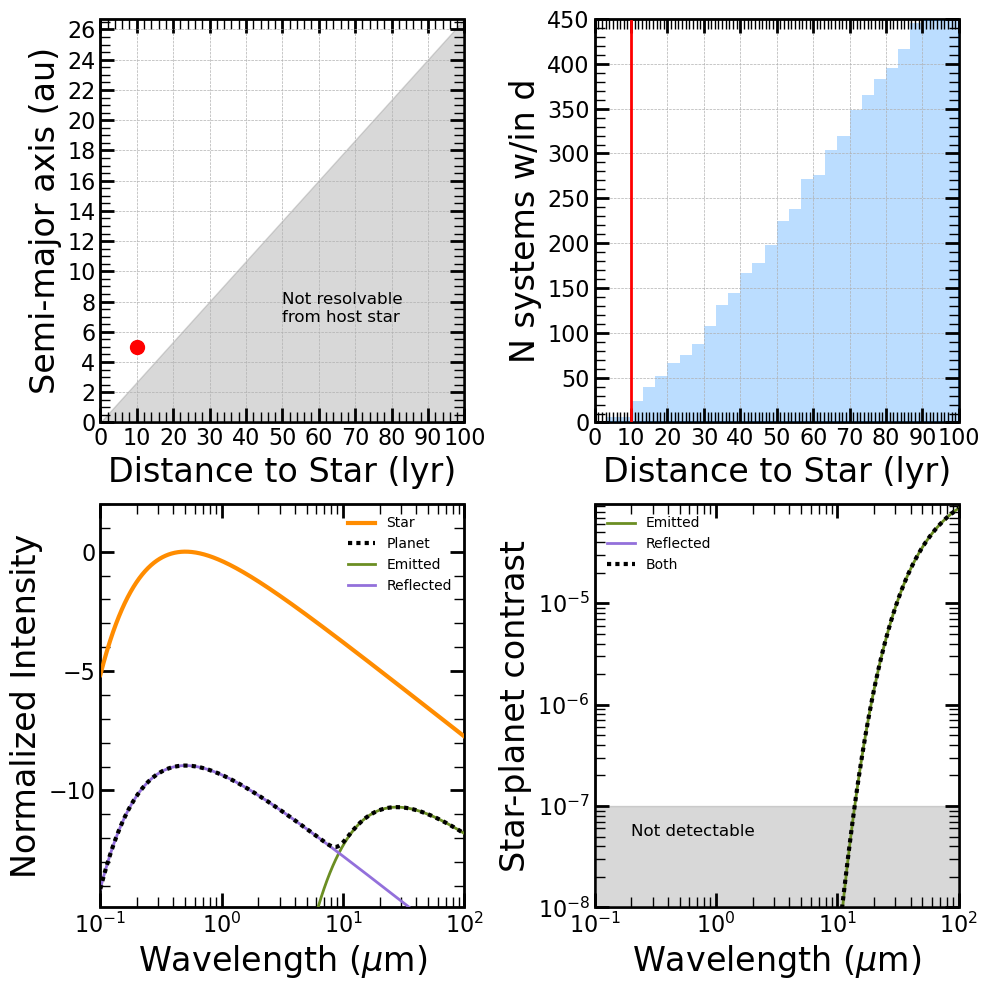

In [2]:
#------------------------INPUTS--------------------------#
params = {
    'telescope diameter': 8.0, #diameter in m
    
    'planet radius': 11.0, #Earth radii
    'planet albedo': 0.5,
    'planet semimajor axis': 5.0, #au

    'star temperature': 5772.0, #K
    'star radius': 1.0, #solar radii

    'distance to star': 10.0 #lyr
}
#--------------------------------------------------------#

direct_imaging_plot(params)

##### <span style="color:white">Astrometry</span>
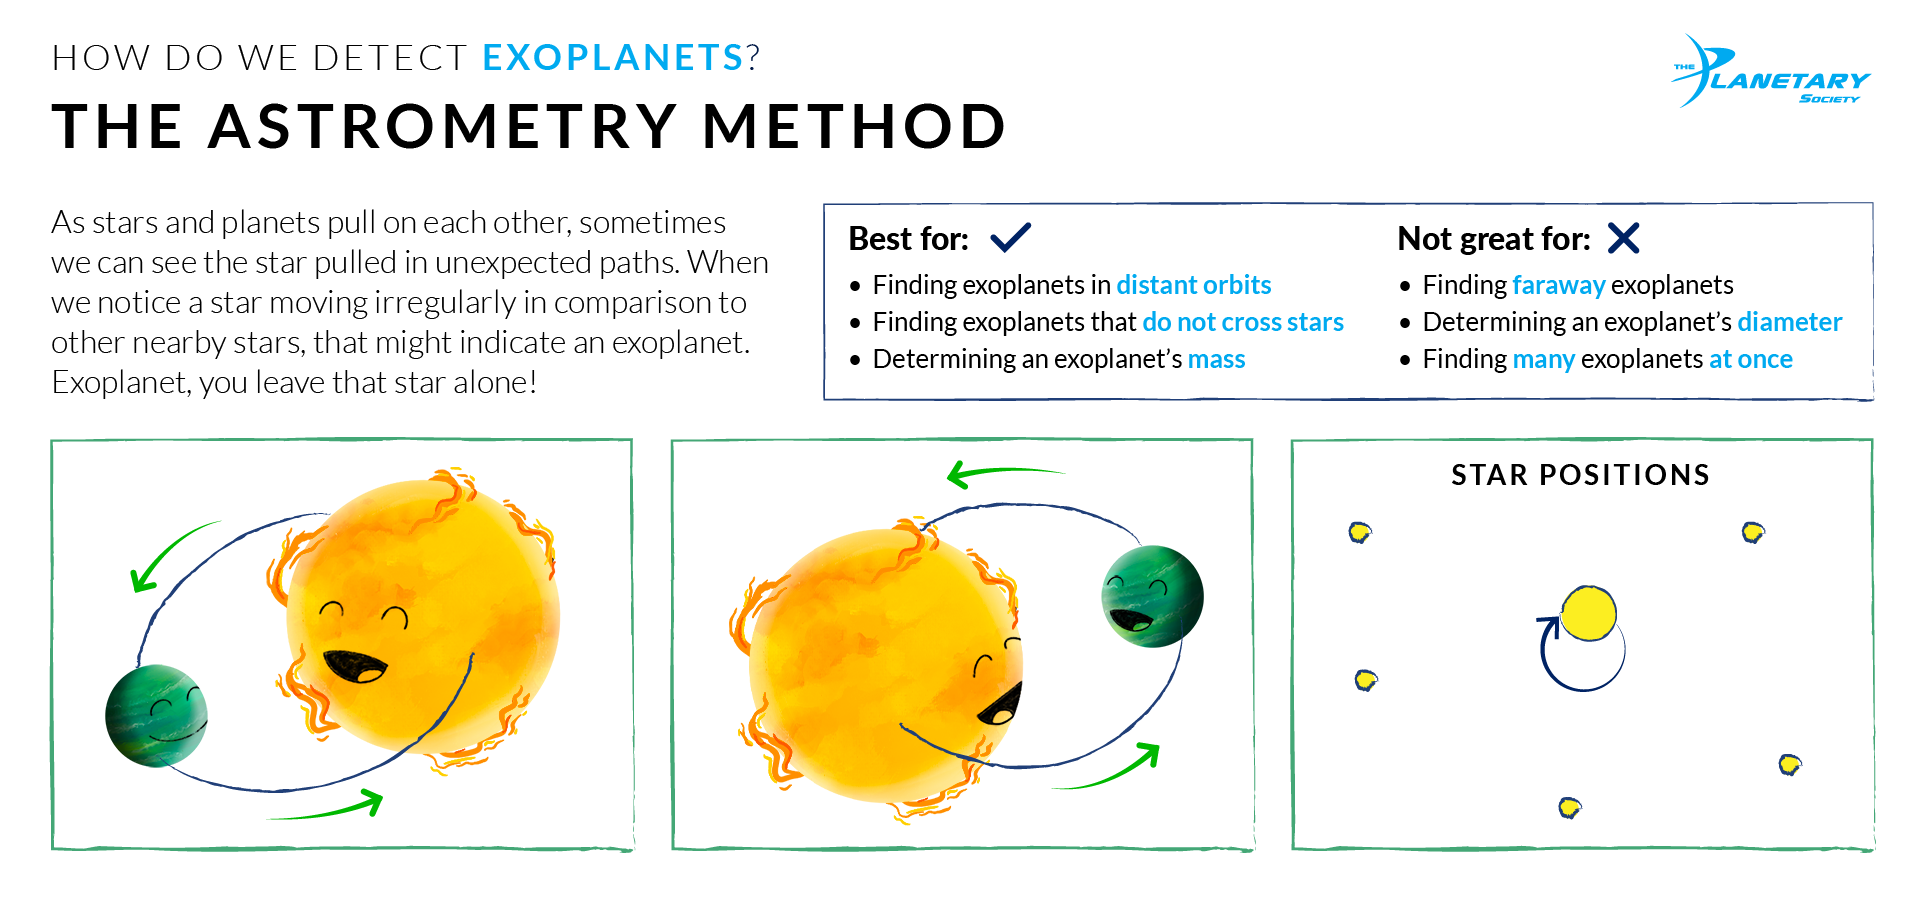

Of the detection methods discussed thus far, astrometry is perhaps the most intuitive and simplist mathematically. However, it remains quite challenging to detect planets via this technique in practice. Like the RV method, detecting planets via astrometry exploits the fact that an unseen planetary companion and its host star orbit their mutual center of mass. If the orbital semi-major axis of the host is large enough relative to the detection limits of our instrument(s), then we can observe the periodic motion of the host star relative to effectively fixed background stars. The astrometric signal $\theta$ of a planet of mass $M_p$ orbiting a star of mass $M_\star$ with a semi-major axis $a$ that is $d$ away from the observer is given by

$$\LARGE\theta = \left(\frac{M_p}{M_\star}\right)\frac{a}{d}.$$

Work with your coursemates to derive this expression and discuss what types of planets are favored by this technique.

Similar to direct imaging, there is a minimum $\theta$ that we can resolve. Plugging in some $\theta_{min}$ and solving for $M_p$ gives the minimum planet mass that we can resolve as a function of $d$, $a$, and $\theta_{min}$.

Rearranging for planet mass (since this is the variable we are trying to measure) gives

$$\LARGE M_{p,min} = \theta_{min} M_\star \frac{d}{a}$$

Just looking at this equation, how does the minimum measureable planet mass change with each of the parameters?

The plot below shows a color map of the minimum detectable planet mass around a star with $M_{star}$ as a function of $a$ and $d$ for an assumed $\theta_{min}$. I have set $\theta_{min}=\theta_{min}\sim 400 \mu \mathrm{as}$ (micro arcseconds) to roughly correspond to a significant signal with a "state-of-the-art" astrometric instrument (e.g., [GRAVITY on VLTI](https://www.eso.org/sci/facilities/paranal/instruments/gravity.html) and [GAIA](https://www.esa.int/Science_Exploration/Space_Science/Gaia_overview), which a precisions of $\sim$10s-100 $\mu$as. Any planet masses specified in the 'mass_levels' array will show up as black lines on the plot. It is currently set up to show Earth, Neptune, and Jupiter mass planets.

### Discuss with your group:
- Can you detect an Earth mass planet with a semi-major axis of 1 AU with this technique?
- Can you detect a Jupiter mass planet with a semi-major axis of 5.2 AU with this technique? How close does the system need to be? Approximately how many systems are within that distance (reference the plot above)?

Text(0, 0.5, '$\\log_{10}$(a/au)')

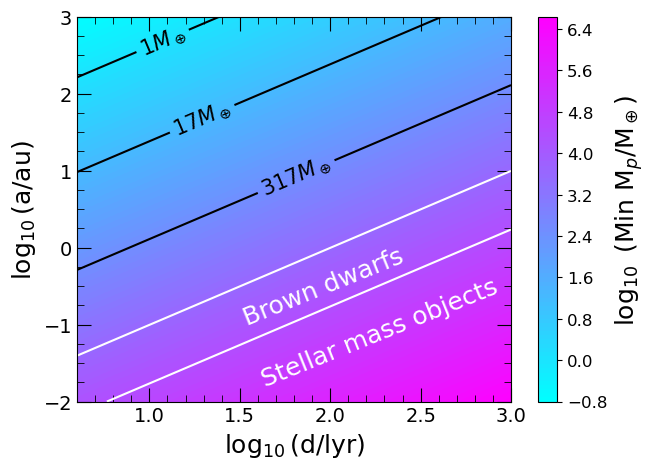

In [3]:
#------------------------------------------------Inputs------------------------------------------------------------#
Mstar = 1.0 #Solar mass units
mass_levels = [1.0, 17.0, 317.0] #Earth mass units
theta_min = 400 #micro arcseconds
#------------------------------------------------------------------------------------------------------------------#

a = np.linspace(0.01, 1000, 1000)
d = np.linspace(4.0, 1000.0, 1000)
d,a = np.meshgrid(d, a)
Z = min_planet_mass_astrometry(Mstar, a, d, theta_min)

plt.figure(figsize = (7,5))
plt.contourf(np.log10(d), np.log10(a), np.log10(Z), levels = 100, cmap = 'cool')
cb = plt.colorbar()
cb.set_label(label = r'$\log_{10}$ (Min M$_p$/M$_\oplus$)', size= 18)
cb.ax.tick_params(labelsize='large')

mass_levels = np.array([np.log10(mass) for mass in mass_levels])
cl = plt.contour(np.log10(d), np.log10(a), np.log10(min_planet_mass_astrometry(Mstar, a, d)), levels = mass_levels, colors = 'k')
plt.contour(np.log10(d), np.log10(a), np.log10(min_planet_mass_astrometry(Mstar, a, d)), levels = [np.log10(317.0*13), np.log10(317.0*75)], colors = 'w')
plt.text(1.5, -1.0, 'Brown dwarfs', fontsize = 18, rotation = 22, color = 'w')
plt.text(1.6, -1.8, 'Stellar mass objects', fontsize = 18, rotation = 22, color = 'w')

def fmt(x):
    x = 10**x
    s = f"{x:.1f}"
    if s.endswith("0"):
        s = f"{x:.0f}"
    return s + r'$M_\oplus$'   
plt.clabel(cl, cl.levels, fmt = fmt, fontsize = 15)
    

plt.xticks(np.linspace(0.5, 3.0, int(2.5/0.1)+1), minor = True)
plt.xlim(0.6, 3)

plt.yticks(np.linspace(-2, 3.0, int(5/0.25)+1), minor = True)
#plt.xlim(0.6, 3)

plt.tick_params(which = 'major', labelsize = 14, top = True, right = True, direction = 'in', length = 10)
plt.tick_params(which = 'minor', labelsize = 14, top = True, right = True, direction = 'in', length = 5)

plt.xlabel(r'$\log_{10}$(d/lyr)', fontsize = 18)
plt.ylabel(r'$\log_{10}$(a/au)', fontsize = 18)

#plt.axhline(np.log10(5.2))


### Given what you've learned in this module, do any of the numbers below surprise you?

In [4]:
pldata = pd.read_csv('./data/PS_2026.07.24_07.42.56.csv')
print('Total planet detections = ', len(pldata))
print('Detections by Astrometry = ', len(np.where(pldata['discoverymethod'] == 'Astrometry')[0]))
print('Detections by imaging = ', len(np.where(pldata['discoverymethod'] == 'Imaging')[0]))

Total planet detections =  6267
Detections by Astrometry =  6
Detections by imaging =  95
